# **Proyecto Final GHIGI - Data Science 1**


---



#Abstract

Este proyecto tiene como objetivo analizar un conjunto de datos perteneciente a la industria cinematográfica, con información detallada sobre miles de películas de distintos géneros, países y productoras. A través de un análisis exploratorio de datos (EDA) se busca identificar patrones relevantes, relaciones entre variables y factores que podrían influir en el éxito comercial o en la valoración del público.

El dataset contiene información numérica (como presupuesto, ingresos, popularidad o duración) y categórica (como género, idioma, país o estado de producción), lo cual permite realizar comparaciones entre diferentes tipos de películas y evaluar el comportamiento de los datos desde múltiples perspectivas.

Este análisis permitirá detectar valores atípicos, posibles correlaciones entre presupuesto e ingresos, así como también explorar cómo características como el idioma, el género o la productora pueden impactar en la calificación promedio. A partir de visualizaciones gráficas y medidas estadísticas, se buscará comprender mejor los factores asociados a la calidad y rentabilidad de una película.

El proyecto se estructura en distintas etapas: revisión de los datos y limpieza inicial, análisis univariado, bivariado y multivariado, tratamiento de valores nulos y outliers, y una sección final con las principales conclusiones y observaciones obtenidas. En etapas posteriores, estos resultados podrían servir como base para la creación de modelos predictivos que estimen la recaudación o la valoración de futuras producciones cinematográficas.

#Preguntas / Hipotesis de interés


¿Existe una relación entre el presupuesto de una película y su nivel de ingresos?

¿Las películas con mayor popularidad tienden a recibir mejores calificaciones?

¿Qué géneros son los que presentan, en promedio, mayores ganancias?

¿Las películas con mayor presupuesto tienden a recibir mejores calificaciones promedio?

¿La duración de una película (runtime) está asociada con su rendimiento económico o su calidad percibida?

¿Existen outliers que afecten los resultados de análisis, especialmente en variables financieras como presupuesto o revenue?

#Objetivo del proyecto

El objetivo de este proyecto es realizar un análisis exploratorio del dataset de películas con el fin de identificar relaciones significativas entre las variables que puedan explicar diferencias en la calidad y el éxito comercial de las producciones. A partir de la limpieza, visualización y tratamiento de los datos, se busca comprender cómo factores como el presupuesto, el género o la duración inciden en la calificación promedio y los ingresos.

#Diccionario de Columnas

|       Columnas       | Tipo de dato |                             Descripción                            |
| :------------------: | :----------: | :----------------------------------------------------------------: |
|         title        |    object    |                       Nombre de la película.                       |
|        genres        |    object    |            Género o categoría principal de la película.            |
|   language  |    object    |        Idioma original en el que fue producida la película.        |
| production_companies |    object    |      Nombre de la compañía o estudio que produjo la película.      |
| production_countries |    object    |             País o países donde se produjo la película.            |
|     release_date     |    object    |                  Fecha de estreno de la película.                  |
|        status        |    object    |   Estado de producción (por ejemplo: Released, Post Production).   |
|       director       |    object    |                   Nombre del director principal.                   |
|        budget        |      int     | Presupuesto destinado a la producción de la película (en dólares). |
|        revenue       |      int     |          Ingresos generados por la película (en dólares).          |
|        runtime       |      int     |              Duración total de la película en minutos.             |
|      popularity      |     float    |    Índice de popularidad basado en búsquedas y visualizaciones.    |
|     vote_average     |     float    |           Calificación promedio otorgada por el público.           |
|      vote_count      |      int     |            Cantidad de votos recibidos por la película.            |


---
# Importación de librerías y carga de dataset

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import codecs
import re
import json

In [34]:
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")

In [35]:
movies_ds = "movies.csv"
movies_df = pd.read_csv(movies_ds)

# Limpieza y Ordenamiento de datos

In [36]:
# Eliminación de columnas que no se usarán
cols_drop = [
    'index', 'id', 'homepage', 'tagline',
    'keywords', 'overview', 'cast', 'crew', 'original_title', 'original_language'
]

movies_df = movies_df.drop(columns=cols_drop, errors='ignore')
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4775 non-null   object 
 2   popularity            4803 non-null   float64
 3   production_companies  4803 non-null   object 
 4   production_countries  4803 non-null   object 
 5   release_date          4802 non-null   object 
 6   revenue               4803 non-null   int64  
 7   runtime               4801 non-null   float64
 8   spoken_languages      4803 non-null   object 
 9   status                4803 non-null   object 
 10  title                 4803 non-null   object 
 11  vote_average          4803 non-null   float64
 12  vote_count            4803 non-null   int64  
 13  director              4773 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 525.5+ KB


In [37]:
# Renombramiento de columna
movies_df = movies_df.rename(columns={"spoken_languages": "language"})

In [38]:
# Limpieza de columnas
cols_json = ["production_companies", "production_countries", "language"]
def extract_first_name(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s == "" or s == "[]":
        return np.nan
    m = re.search(r'"name"\s*:\s*"([^"]+)"', s)
    return m.group(1) if m else np.nan

for col in ["production_companies", "production_countries", "language"]:
    movies_df[col] = movies_df[col].apply(extract_first_name)

#------------------------------------------------------

for col in ["production_companies", "production_countries", "language"]:
    movies_df[col] = movies_df[col].apply(
        lambda s: codecs.decode(s, 'unicode_escape') if isinstance(s, str) else s
    )

for col in ["production_companies", "production_countries", "language"]:
    movies_df[col] = movies_df[col].str.strip()

movies_df[["production_companies","production_countries","language"]].head(10)

movies_df[cols_json].head(5)

,production_companies,production_countries,language
0,Ingenious Film Partners,United States of America,English
1,Walt Disney Pictures,United States of America,English
2,Columbia Pictures,United Kingdom,Français
3,Legendary Pictures,United States of America,English
4,Walt Disney Pictures,United States of America,English


Las columnas production_companies, production_countries y language contenían datos en formato JSON.
Se aplicó un proceso de extracción para obtener únicamente los nombres dentro de cada campo, facilitando la lectura y el análisis posterior.
De esta forma, se conservaron los valores relevantes sin modificar la información original.

# Revision y tratamiento de valores nulos y duplicados

In [39]:
# Revision de duplicados
duplicados = movies_df.duplicated().sum()
print(f"🔁 Duplicados encontrados: {duplicados}")

🔁 Duplicados encontrados: 0


Se realizó una revisión de registros duplicados en el dataset.
No se identificaron filas repetidas, por lo que no fue necesario aplicar eliminación.
Esto asegura que cada observación represente una película única dentro del análisis.

In [40]:
# Revision de nulos
nulos = movies_df.isna().sum().sort_values(ascending=False)
print("\n🔍 Valores nulos por columna:\n")
print(nulos)


🔍 Valores nulos por columna:

production_companies    351
production_countries    174
language                 87
director                 30
genres                   28
runtime                   2
release_date              1
budget                    0
popularity                0
revenue                   0
status                    0
title                     0
vote_average              0
vote_count                0
dtype: int64


In [41]:
# Porcentaje de nulos
porcentaje_nulos = (movies_df.isna().mean() * 100).round(2)
print("\n📉 Porcentaje de nulos por columna:\n")
print(porcentaje_nulos)


📉 Porcentaje de nulos por columna:

budget                  0.00
genres                  0.58
popularity              0.00
production_companies    7.31
production_countries    3.62
release_date            0.02
revenue                 0.00
runtime                 0.04
language                1.81
status                  0.00
title                   0.00
vote_average            0.00
vote_count              0.00
director                0.62
dtype: float64


/tmp/ipython-input-709775955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index, palette="crest")


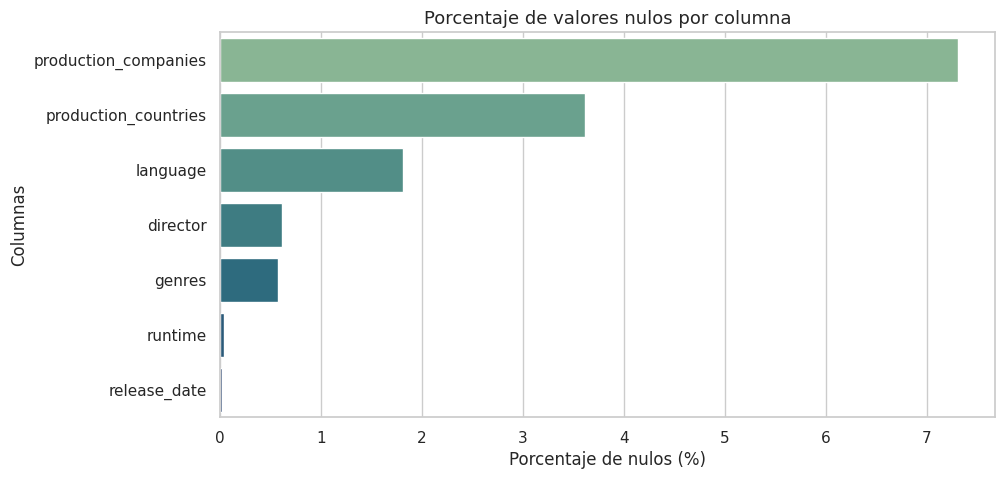

In [42]:
# Visualización rápida de nulos (gráfico)
porcentaje_nulos = (movies_df.isna().mean() * 100).round(2)
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index, palette="crest")
plt.title("Porcentaje de valores nulos por columna", fontsize=13)
plt.xlabel("Porcentaje de nulos (%)")
plt.ylabel("Columnas")
plt.show()

In [43]:
# Tratamiento de nulos
cols_categoricas = ["production_companies","production_countries","language","director","genres"]
movies_df[cols_categoricas] = movies_df[cols_categoricas].fillna("No informado")

movies_df["runtime"] = movies_df["runtime"].fillna(movies_df["runtime"].median())
movies_df["release_date"] = movies_df["release_date"].fillna("Sin fecha")

In [44]:
# Comprobación de valores nulos
movies_df.isna().sum()

,0
budget,0
genres,0
popularity,0
production_companies,0
production_countries,0
release_date,0
revenue,0
runtime,0
language,0
status,0


Se detectaron valores nulos en algunas variables categóricas como production_companies, production_countries y director.
Para mantener la consistencia del dataset, se imputaron con el valor "No informado".
En el caso de la variable release_date, el valor faltante se reemplazó por "Sin fecha", mientras que las numéricas sin datos fueron completadas con la mediana correspondiente.

# Detección y Tratamiento de Outliers

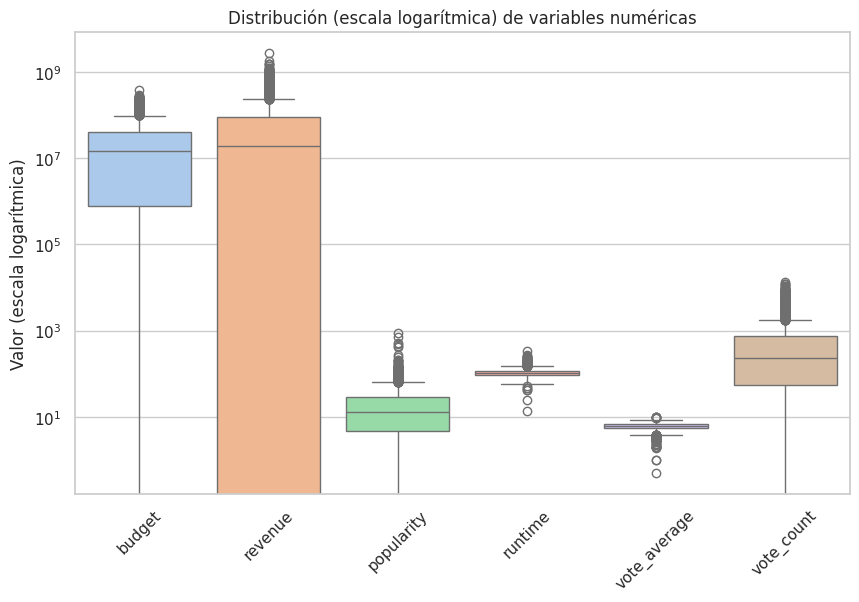

In [45]:
# Visualización rapida de outliers (grafico)
num_cols = ["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]

plt.figure(figsize=(10,6))
sns.boxplot(data=movies_df[["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]])
plt.yscale("log")
plt.title("Distribución (escala logarítmica) de variables numéricas")
plt.ylabel("Valor (escala logarítmica)")
plt.xticks(rotation=45)
plt.show()

In [46]:
# Detección numerica de outliers principales
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

out_budget, lim_inf_b, lim_sup_b = detectar_outliers_iqr(movies_df, "budget")
out_revenue, lim_inf_r, lim_sup_r = detectar_outliers_iqr(movies_df, "revenue")

print(f" Outliers en 'budget': {len(out_budget)} registros")
print(f" Outliers en 'revenue': {len(out_revenue)} registros")
print(f" Límites budget: {lim_inf_b:.0f} - {lim_sup_b:.0f}")
print(f" Límites revenue: {lim_inf_r:.0f} - {lim_sup_r:.0f}")

 Outliers en 'budget': 321 registros
 Outliers en 'revenue': 472 registros
 Límites budget: -58025000 - 98815000
 Límites revenue: -139375780 - 232292968


Los valores atípicos en budget y revenue corresponden a grandes producciones reales, por lo que no se eliminaron ni modificaron.
Se mantuvieron para preservar la información original, aplicando solo un recorte visual con fines gráficos.

# Análisis Exploratorio de Datos (EDA)

En esta sección se analizan las principales variables del dataset con el objetivo de identificar tendencias, distribuciones y relaciones entre los distintos indicadores.
Se presentan visualizaciones univariadas, bivariadas y multivariadas acompañadas de sus interpretaciones.

In [47]:
bins = [0, 5, 7, 8, 10]
labels = ["Baja", "Media", "Buena", "Excelente"]
movies_df["rango_calificacion"] = pd.cut(movies_df["vote_average"], bins=bins, labels=labels, right=False)


<Axes: xlabel='rango_calificacion', ylabel='count'>

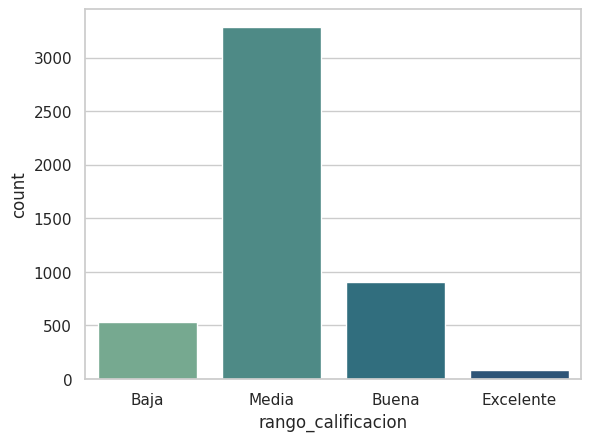

In [48]:
sns.countplot(data=movies_df, x="rango_calificacion", hue="rango_calificacion", palette="crest", legend=False)

Se generó la variable rango_calificacion, que agrupa las puntuaciones promedio (vote_average) en cuatro niveles: baja, media, buena y excelente.
Esta clasificación permite observar de forma más clara cómo se distribuyen las valoraciones y facilita el análisis de tendencias en los distintos grupos de películas.

In [49]:
q1, q2, q3 = movies_df["budget"].quantile([0.25, 0.5, 0.75])
def clasificar_presupuesto(x):
    if x < q1: return "Bajo"
    elif x < q3: return "Medio"
    else: return "Alto"
movies_df["nivel_presupuesto"] = movies_df["budget"].apply(clasificar_presupuesto)

<Axes: xlabel='nivel_presupuesto', ylabel='count'>

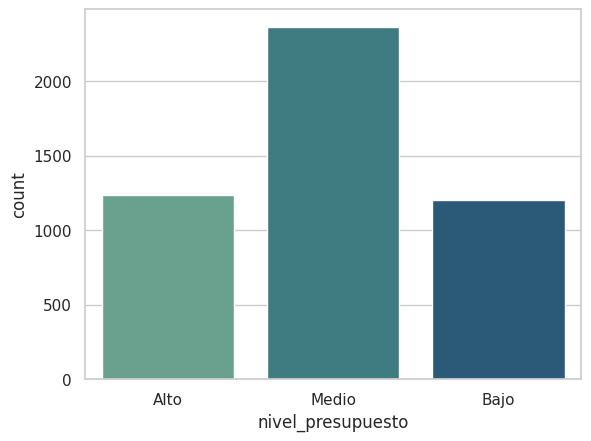

In [50]:
sns.countplot(data=movies_df, x="nivel_presupuesto", hue="nivel_presupuesto", palette="crest", legend=False)

Se creó una nueva variable nivel_presupuesto con el objetivo de clasificar las películas según su presupuesto en tres rangos: bajo, medio y alto.
Esta segmentación facilita la comparación entre producciones de distintas escalas y permite analizar cómo el presupuesto influye en la recaudación y popularidad.

In [51]:
# Cambio de tipo de dato de la columna release_date
movies_df["release_date"] = pd.to_datetime(movies_df["release_date"], errors="coerce")

# Analisis Univariado

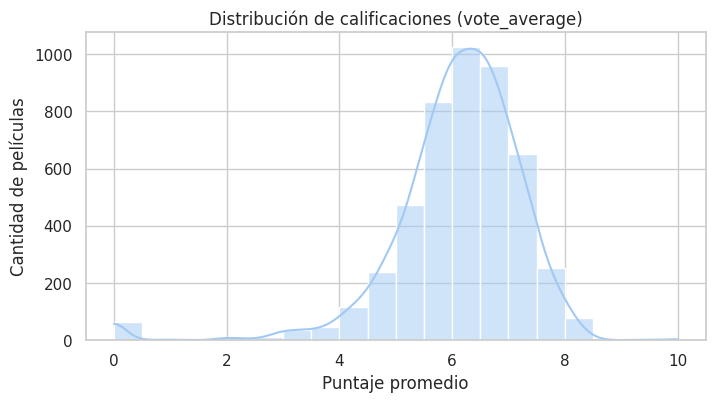

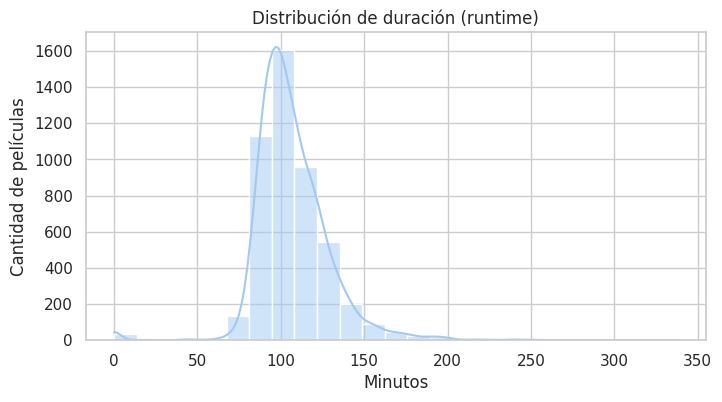

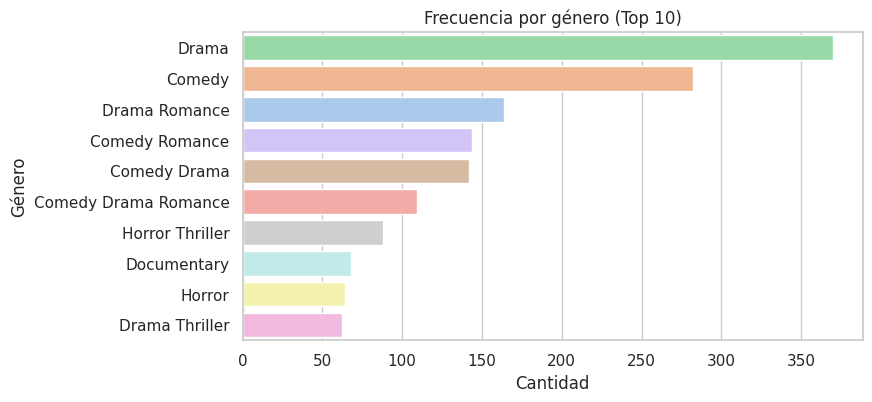

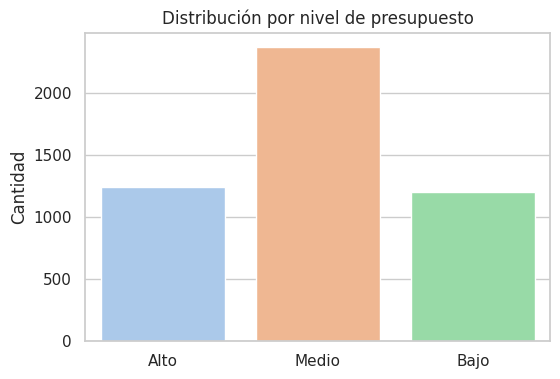

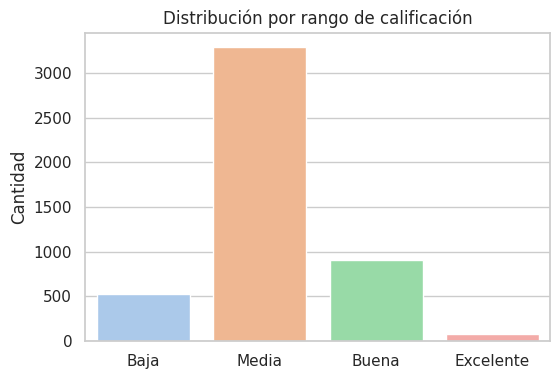

In [52]:
# Aseguro columnas derivadas por si aún no existen
if "año_estreno" not in movies_df.columns:
    movies_df["año_estreno"] = pd.to_datetime(movies_df["release_date"], errors="coerce").dt.year

# 1) Calificaciones
plt.figure(figsize=(8,4))
sns.histplot(movies_df["vote_average"], bins=20, kde=True)
plt.title("Distribución de calificaciones (vote_average)")
plt.xlabel("Puntaje promedio"); plt.ylabel("Cantidad de películas")
plt.show()

# 2) Duración
plt.figure(figsize=(8,4))
sns.histplot(movies_df["runtime"], bins=25, kde=True)
plt.title("Distribución de duración (runtime)")
plt.xlabel("Minutos"); plt.ylabel("Cantidad de películas")
plt.show()

# 3) Géneros (Top 10)
top_genres = movies_df["genres"].value_counts().head(10).index
plt.figure(figsize=(8,4))
sns.countplot(
    data=movies_df[movies_df["genres"].isin(top_genres)],
    y="genres", hue="genres", legend=False, order=top_genres
)
plt.title("Frecuencia por género (Top 10)")
plt.ylabel("Género"); plt.xlabel("Cantidad")
plt.show()

# 4) Niveles (si creaste 'nivel_presupuesto' y 'rango_calificacion')
if "nivel_presupuesto" in movies_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=movies_df, x="nivel_presupuesto", hue="nivel_presupuesto", legend=False)
    plt.title("Distribución por nivel de presupuesto"); plt.xlabel(""); plt.ylabel("Cantidad")
    plt.show()

if "rango_calificacion" in movies_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=movies_df, x="rango_calificacion", hue="rango_calificacion", legend=False)
    plt.title("Distribución por rango de calificación"); plt.xlabel(""); plt.ylabel("Cantidad")
    plt.show()

Las calificaciones se concentran entre 5 y 8; la mayoría de las películas duran ~90-120 minutos; los géneros más frecuentes dominan la muestra y servirán para comparaciones posteriores.

# Analisis Bivariado

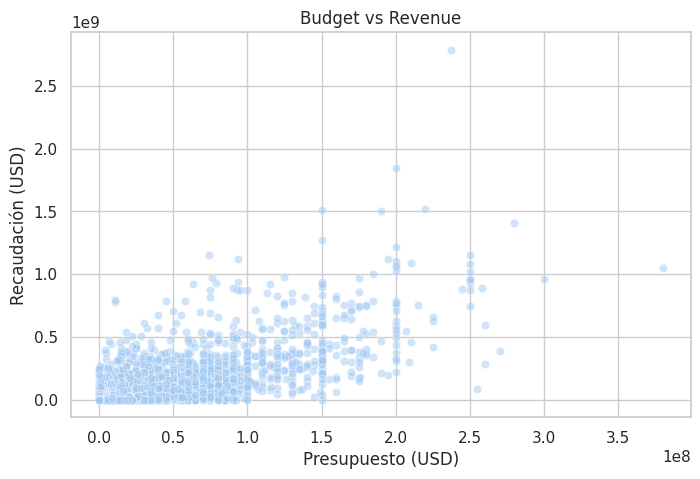

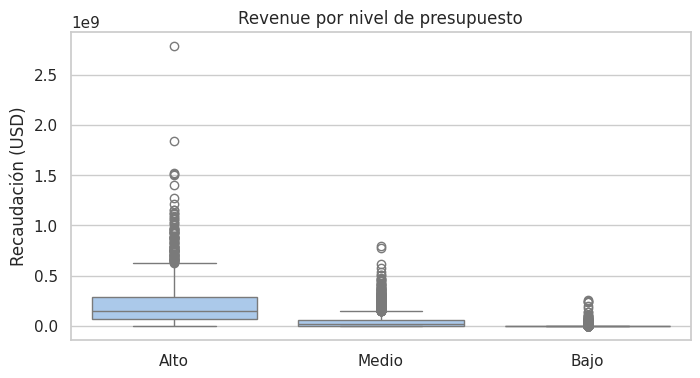

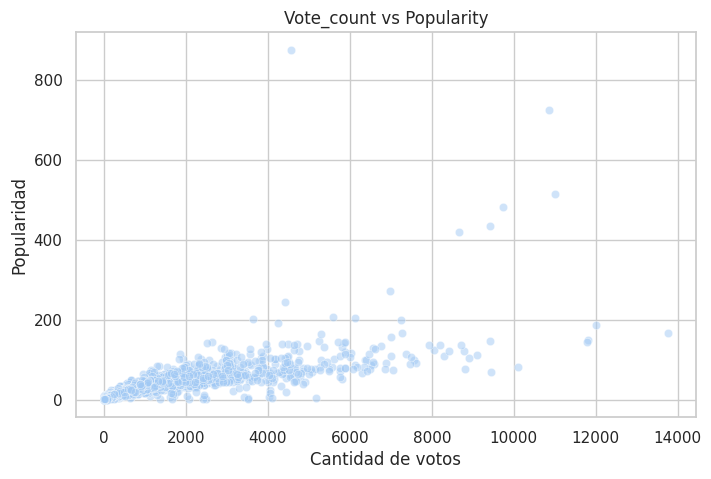

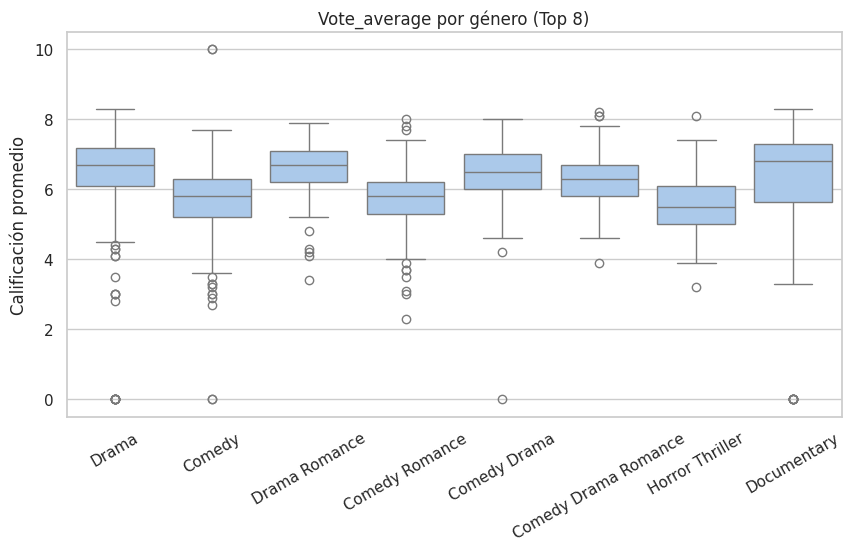

In [53]:
# 1) Presupuesto vs Recaudación
plt.figure(figsize=(8,5))
sns.scatterplot(data=movies_df, x="budget", y="revenue", alpha=0.5)
plt.title("Budget vs Revenue"); plt.xlabel("Presupuesto (USD)"); plt.ylabel("Recaudación (USD)")
plt.show()

# 2) Recaudación por nivel de presupuesto (si existe)
if "nivel_presupuesto" in movies_df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=movies_df, x="nivel_presupuesto", y="revenue")
    plt.title("Revenue por nivel de presupuesto"); plt.xlabel(""); plt.ylabel("Recaudación (USD)")
    plt.show()

# 3) Popularidad vs Cantidad de votos
plt.figure(figsize=(8,5))
sns.scatterplot(data=movies_df, x="vote_count", y="popularity", alpha=0.5)
plt.title("Vote_count vs Popularity"); plt.xlabel("Cantidad de votos"); plt.ylabel("Popularidad")
plt.show()

# 4) Calificación por género (Top 8)
top8 = movies_df["genres"].value_counts().head(8).index
plt.figure(figsize=(10,5))
sns.boxplot(
    data=movies_df[movies_df["genres"].isin(top8)],
    x="genres", y="vote_average", order=top8
)
plt.title("Vote_average por género (Top 8)"); plt.xlabel(""); plt.ylabel("Calificación promedio")
plt.xticks(rotation=30)
plt.show()

Existe relación positiva entre presupuesto e ingresos; más votos suelen asociarse a mayor popularidad; hay diferencias de calificación entre géneros.

# Analisis Multivariado

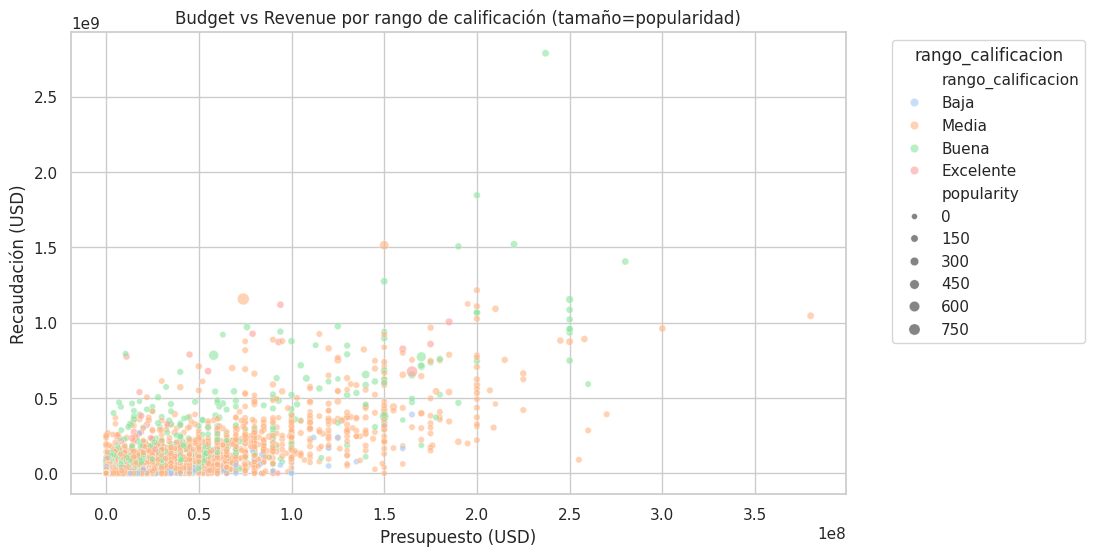

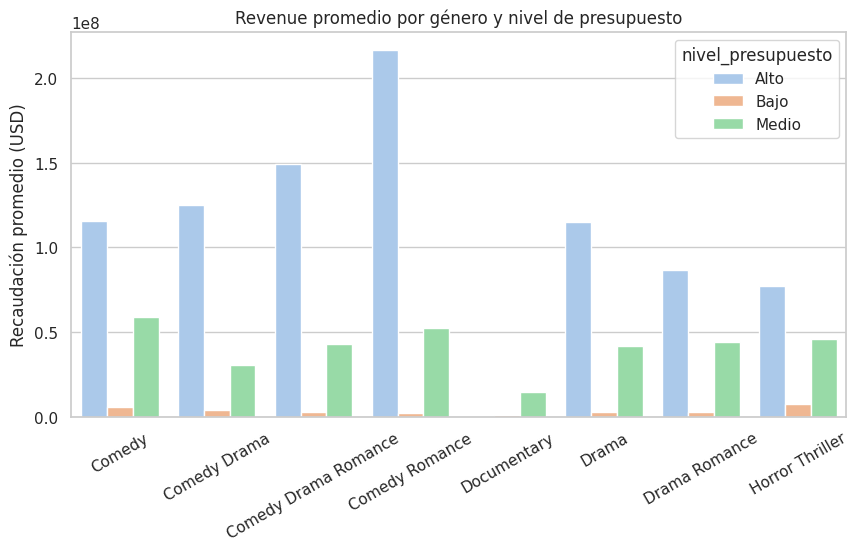

In [54]:
# A) Presupuesto vs Recaudación coloreado por rango de calificación y tamaño = popularidad
hue_col = "rango_calificacion" if "rango_calificacion" in movies_df.columns else None

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=movies_df, x="budget", y="revenue",
    hue=hue_col, size="popularity", alpha=0.6
)
plt.title("Budget vs Revenue por rango de calificación (tamaño=popularidad)")
plt.xlabel("Presupuesto (USD)"); plt.ylabel("Recaudación (USD)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title=hue_col if hue_col else "Leyenda")
plt.show()

# B) Recaudación promedio por género y nivel de presupuesto (si existe)
if "nivel_presupuesto" in movies_df.columns:
    g = movies_df[movies_df["genres"].isin(top8)].groupby(["genres","nivel_presupuesto"])["revenue"].mean().reset_index()
    plt.figure(figsize=(10,5))
    sns.barplot(data=g, x="genres", y="revenue", hue="nivel_presupuesto")
    plt.title("Revenue promedio por género y nivel de presupuesto")
    plt.xlabel(""); plt.ylabel("Recaudación promedio (USD)")
    plt.xticks(rotation=30)
    plt.show()

Al añadir calificación y popularidad, se observa que las producciones con mayores presupuestos concentran mayores ingresos y suelen ubicarse en rangos de calificación medios-altos.

# Correlaciones

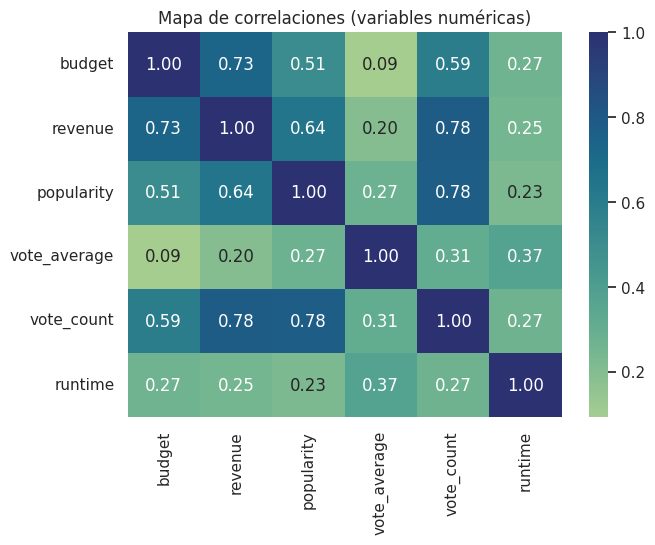

In [55]:
num_cols = ["budget","revenue","popularity","vote_average","vote_count","runtime"]
corr = movies_df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="crest", fmt=".2f")
plt.title("Mapa de correlaciones (variables numéricas)")
plt.show()

El presupuesto y la recaudación presentan la mayor correlación positiva; la cantidad de votos y la popularidad también se asocian fuertemente. La calificación media (vote_average) no muestra relación fuerte con popularidad o ingresos.

# Preparación de los datos para el modelo de regresión

## Definición de la variable objetivo (revenue_log)

In [56]:
movies_df["revenue_log"] = np.log1p(movies_df["revenue"])

Para el modelo de regresión se utilizó como variable objetivo la recaudación de cada película (`revenue`).
Debido a que esta variable presenta valores muy grandes y una distribución altamente asimétrica, se aplicó una transformación logarítmica mediante `log1p`, creando la nueva variable `revenue_log`.
Esto estabiliza la escala y facilita el aprendizaje del modelo.

## Selección de variables explicativas (features)

In [57]:
# Seleccionamos las variables con las que trabajaremos
num_cols = ["budget", "runtime", "popularity", "vote_count", "vote_average", "año_estreno"]

cat_cols = [
    "genres",
    "production_companies",
    "production_countries",
    "language",
    "director",
    "nivel_presupuesto",
    "rango_calificacion"
]

In [58]:
# Columnas que se usan en el modelo (features + target)
columnas_modelo = num_cols + cat_cols + ["revenue_log"]

# Eliminamos filas con NaN en cualquiera de estas columnas
movies_model = movies_df.dropna(subset=columnas_modelo).copy()

# Redefinimos X e y a partir del dataframe filtrado
X = movies_model[num_cols + cat_cols].copy()
y = movies_model["revenue_log"].copy()

Antes de realizar el train/test split se eliminaron las filas que aún contenían valores faltantes en las variables utilizadas por el modelo. Esto evita errores durante la etapa de selección de características y entrenamiento.


Como variables explicativas se seleccionaron tanto variables numéricas (`budget`, `runtime`, `popularity`, `vote_count`, `vote_average`, `año_estreno`) como categóricas (`genres`, `production_companies`, `production_countries`, `language`, `director`, `nivel_presupuesto`, `rango_calificacion`).

Estas variables representan información relevante sobre cada película y se utilizarán como componentes para predecir la recaudación transformada (`revenue_log`).

## División en conjunto de entrenamiento y prueba

In [59]:
# Importamos la función para dividir el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Dividimos los datos en:
# - X_train y y_train: datos utilizados para entrenar el modelo (80%)
# - X_test y y_test: datos utilizados para evaluar el modelo (20%)
# El parámetro random_state asegura que siempre obtengamos la misma división
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Para evaluar el modelo de forma correcta se dividieron los datos en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%) utilizando `train_test_split`.
El conjunto de entrenamiento se emplea para ajustar el modelo, mientras que el conjunto de prueba se reserva para medir el desempeño sobre datos no vistos, para evitar que el modelo simplemente memorice los ejemplos.

# Preprocesamiento, selección de características y construcción del modelo

## Preprocesamiento de los datos

In [60]:
# Importamos ColumnTransformer para aplicar diferentes transformaciones según el tipo de variable
from sklearn.compose import ColumnTransformer
# Importamos StandardScaler para escalar variables numéricas
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definimos el preprocesamiento para el modelo
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    #cualquier columna NO especificada será descartada
    remainder="drop"
)

Se escalaron las variables numéricas y se aplicó One-Hot Encoding a las categóricas para que el modelo pueda procesar correctamente ambos tipos de información.

## Selección de características (Feature Selection)

In [61]:
# Importamos SelectKBest para seleccionar las mejores variables e importamos f_regression como función estadística para medir su relevancia
from sklearn.feature_selection import SelectKBest, f_regression

# Definimos el selector de características:
# - k=20 indica que queremos quedarnos con las 20 variables más relevantes
selector = SelectKBest(score_func=f_regression, k=20)

Se aplicó SelectKBest para reducir la cantidad de variables generadas tras el One-Hot Encoding y quedarnos solo con las más relevantes para el modelo.

## Modelo de regresión (Ridge Regression)

In [62]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

Se utilizó Ridge Regression porque es estable cuando hay muchas variables y reduce el riesgo de sobreajuste.

## Pipeline del modelo

In [63]:
# Importamos Pipeline
from sklearn.pipeline import Pipeline

# Creamos un pipeline que integra todo el proceso de modelado:
ridge_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("feature_selection", selector),
    ("model", Ridge(alpha=1.0))
])

# Entrenamos el pipeline completo utilizando los datos de entrenamiento
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['budget', 'runtime',
                                                   'popularity', 'vote_count',
                                                   'vote_average',
                                                   'año_estreno']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['genres',
                                                   'production_companies',
                                                   'production_countries',
                                                   'language', 'director',
                                                   'nivel_presupuesto',
                                                   'rango_calificacion'])])),
                ('feature_selection',
                 SelectKBest(k=20,
                             score_func=<function f_regression at 0x79df4ef1ccc0>)),
                ('model', Ridge())])

Se creó un pipeline que integra el preprocesamiento, la selección de características y el modelo final. De esta forma, todos los pasos se aplican en el orden correcto tanto en entrenamiento como en prueba.

# Evaluación del modelo

## Métricas de rendimiento

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicciones del modelo
y_pred = ridge_pipeline.predict(X_test)

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(4.058146287398767, np.float64(5.656397095480472), 0.5254265749861633)

Se evaluó el rendimiento usando las métricas MAE, RMSE y R². Estas permiten medir el error promedio de las predicciones y qué tan bien el modelo explica la variabilidad de la variable objetivo.

## Resultado

El modelo obtuvo un MAE de 4.06, un RMSE de 5.66 y un R² de 0.52. Estos valores muestran que el modelo logra explicar una proporción moderada de la variabilidad de la recaudación, aunque persisten errores significativos en algunos casos. Dado que el fenómeno de estudio presenta alta dispersión y outliers naturales (películas muy taquilleras frente a producciones pequeñas), este desempeño es adecuado para un primer modelo basado en regresión lineal con regularización. El resultado evidencia que existen patrones útiles en los datos, pero también oportunidades de mejora mediante modelos más complejos o técnicas adicionales de ingeniería de variables.


# Conclusiones Finales

A lo largo del proyecto se realizó un análisis completo del dataset de películas, avanzando desde la exploración inicial hasta la construcción y evaluación de un modelo predictivo. En la primera etapa se llevó adelante un proceso de limpieza y preparación de los datos, que incluyó el tratamiento de valores faltantes, la estandarización de columnas, la conversión de campos estructurados en formato JSON y la creación de nuevas variables categóricas. El análisis exploratorio permitió identificar distribuciones relevantes, posibles relaciones entre variables y la presencia de outliers propios del dominio, los cuales se conservaron por corresponder a casos reales del mercado cinematográfico.

En la segunda parte del proyecto se abordó la etapa de modelado. Para ello se definió un pipeline que integró el preprocesamiento (escalado y One-Hot Encoding), la selección de características mediante SelectKBest y la aplicación del modelo Ridge Regression, adecuado para trabajar con alta dimensionalidad. Este enfoque permitió mantener un flujo de trabajo ordenado, reproducible y consistente entre los conjuntos de entrenamiento y prueba.

La evaluación del modelo mostró un MAE de 4.06, un RMSE de 5.66 y un R² de 0.52. Estos resultados indican que el modelo logra capturar una proporción moderada de la variabilidad de la recaudación, algo esperable dado que se trata de un fenómeno altamente disperso y difícil de predecir. Las métricas reflejan un desempeño adecuado para un primer modelo basado en regresión lineal regularizada y evidencian que existen patrones significativos en los datos, aunque todavía hay margen de mejora.

En conjunto, el proyecto permitió recorrer el proceso completo de un workflow de ciencia de datos: limpieza, exploración, ingeniería de variables, selección de características, construcción del modelo, evaluación y conclusiones. Como líneas futuras, sería posible mejorar el desempeño incorporando modelos más complejos (Random Forest, Gradient Boosting), optimizando hiperparámetros o desarrollando nuevas variables que capturen mejor la complejidad del dominio cinematográfico.